In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:99% !important;}
div.cell.code_cell.rendered{width:90%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
span.toc-item-num{display:none;}
div.text_cell_render ul li{font-size:16pt;padding:5px;}
div.CodeMirror-lines > div {padding-left:10px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [1]:
import numpy as np
import pandas as pd
import sys
from tensorflow.keras import utils # utils.to_categorical
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 로지스틱회귀분석(이진분류)
## 1. 데이터셋 생성 & 전처리

In [2]:
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None, encoding='cp949')
df.values[:2]
# 결측치 없으므로, csv파일을 바로 넘파이 배열로 읽어올 예정

array([[  6.   , 148.   ,  72.   ,  35.   ,   0.   ,  33.6  ,   0.627,
         50.   ,   1.   ],
       [  1.   ,  85.   ,  66.   ,  29.   ,   0.   ,  26.6  ,   0.351,
         31.   ,   0.   ]])

In [3]:
# 타겟 변수의 균형
df[8].value_counts()

0    500
1    268
Name: 8, dtype: int64

In [9]:
# np.set_printoptions(threshold=sys.maxsize)

In [ ]:
# 1. 임신횟수
# 2. 2시간내 포도당 농도
# 3. 혈압
# 4. 피부접힘 두께
# 5. 인슐린수치
# 6. BMI체질량지수
# 7. 가족력
# 8. 나이
# 9. 당뇨병발병여부

In [2]:
# csv파일을 numpy 배열로 읽어오기 np.loadtxt(), np.genfromtxt() #이 있는 행은 제외하여 읽어옴
dataset = np.loadtxt('data/pima-indians-diabetes.csv', delimiter=',')
dataset.shape

(768, 9)

In [3]:
# 데이터 분할 : 학습데이터셋(모델학습용)+시험데이터셋(모델평가용)
X_train = dataset[:650, :-1]
y_train = dataset[:650, -1]
X_test  = dataset[650:, :-1]
y_test  = dataset[650:, -1]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((650, 8), (650,), (118, 8), (118,))

## 2. 모델 구성

In [4]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                288       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 833
Trainable params: 833
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [5]:
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])

## 4. 학습

In [6]:
%%time
hist = model.fit(X_train, y_train, # 훈련데이터
                 epochs=200,
                 batch_size=350,
                 # validation_split=0.2, # 검증 데이터 비율(훈련데이터셋 중 20%를 검증용 데이터로)
#                  validation_data=(X_test, y_test),
                 verbose=0
                )

CPU times: total: 8.84 s
Wall time: 8.56 s


## 5. 모델 평가하기(학습과정보기, 평가)

In [7]:
hist.history.keys()

dict_keys(['loss', 'binary_accuracy'])

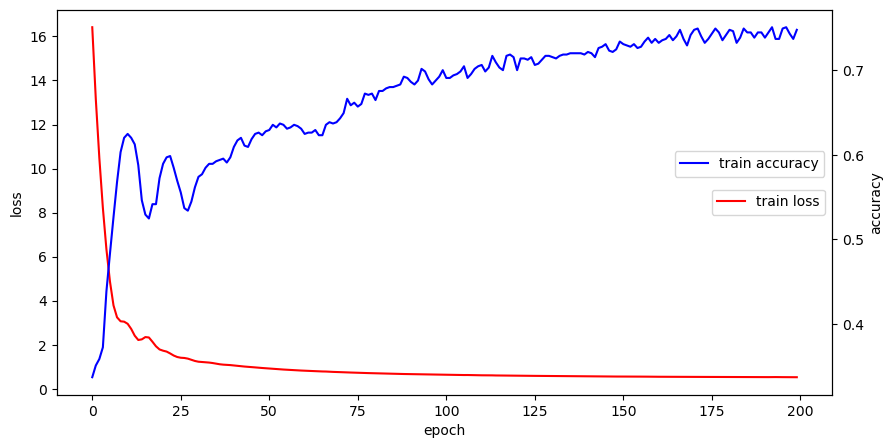

In [8]:
# 학습과정 표시하기(validation dataset 없는 경우)
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], 'r', label='train loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['binary_accuracy'], 'b', label='train accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend(bbox_to_anchor=(0.999, 0.65))
plt.show()

In [9]:
# 모델 평가(X)
model.evaluate(X_train, y_train)

21/21 [==============================] - 0s 8ms/step - loss: 0.5257 - binary_accuracy: 0.7538


[0.5256910920143127, 0.7538461685180664]

In [10]:
# 모델 평가(o)
score = model.evaluate(X_test, y_test)
print("loss : {}, 정확도 : {}%".format(score[0], score[1]*100))

4/4 [==============================] - 0s 6ms/step - loss: 0.6942 - binary_accuracy: 0.6271
loss : 0.6941752433776855, 정확도 : 62.711864709854126%


## 7. 교차표
- 테스트 데이터셋의 실제값(y_test)과 예측값

In [19]:
y_hat = (model.predict(X_test)>0.5).astype(int)
TN=0; FP=0; FN=0; TP=0
# y_hat.shape, y_test.shape
for y, h in zip(y_test.reshape(-1), y_hat.reshape(-1)):
    if h==0 and y==0:
        TN += 1
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
print(TN, FP)
print(FN, TP)

4/4 [==============================] - 0s 5ms/step
60 13
31 14


In [23]:
ctab = pd.crosstab(y_test, y_hat.reshape(-1))
ctab.index.name = '실제값'
ctab.columns.name='예측값'
ctab

ctab = pd.crosstab(y_test, y_hat.reshape(-1),
                  rownames=['실제값'],
                  colnames=['예측값'])
ctab

예측값,0,1
실제값,,
0.0,60,13
1.0,31,14


In [18]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat.reshape(-1))

array([[60, 13],
       [31, 14]], dtype=int64)

# 8.  모델 사용

In [11]:
X_train[10], y_train[10]

(array([  4.   , 110.   ,  92.   ,   0.   ,   0.   ,  37.6  ,   0.191,
         30.   ]),
 0.0)

In [14]:
model.predict([[ 4.   , 110.   ,  92.   ,   0.   ,   0.   ,  37.6  ,   0.191,    30.  ]])>=0.5

1/1 [==============================] - 0s 73ms/step


array([[False]])

In [15]:
(model.predict([[4, 110, 92, 0, 0, 37.6, 0.191, 30],
                   [6, 148, 72, 35, 0, 33.6, 0.6, 45]]) > 0.5).astype(int)

1/1 [==============================] - 0s 65ms/step


array([[0],
       [0]])

# 분류분석
```
1. 데이터셋 생성 및 전처리 : 훈련셋600, 검증셋100, 테스트셋68으로 분리, 종속변수의 원핫인코딩
2. 모델생성(input 8, target 2) : 출력층에서의 활성화함수 'softmax'
    * model.summary()에서 파라미터 수 확인
3. 모델학습과정 설정 : loss='categorical_crossentropy' metrics=['accuracy']
4. 모델 학습 : validation_data=[X_val, Y_val] 추가해서 학습
5. 모델 학습 평가 : 그래프(hist.history.keys()를 확인후 4가지)
             평가(X_test, Y_test)
             교차표(pd.crosstab 이용)
6. 모델 사용하기 - 예측
              0      1
             0.9912  0.00124
```

In [2]:
import numpy as np
import pandas as pd
import sys
from tensorflow.keras import utils # utils.to_categorical
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

## 1. 데이터셋 생성 및 전처리

In [26]:
dataset = np.loadtxt('data/pima-indians-diabetes.csv', delimiter=',')
dataset.shape

(768, 9)

In [29]:
# 훈련셋600, 검증셋100, 테스트셋68으로 분리
X_train = dataset[:600, :-1]
y_train = dataset[:600, -1]
X_val = dataset[600:700, :-1]
y_val = dataset[600:700, -1]
X_test = dataset[700:, :-1]
y_test = dataset[700:, -1]
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((600, 8), (600,), (100, 8), (100,), (68, 8), (68,))

In [30]:
# 종속변수의 원핫인코딩
Y_train = utils.to_categorical(y_train, 2)
Y_val = utils.to_categorical(y_val, 2)
Y_test = utils.to_categorical(y_test, 2)
X_train.shape, Y_train.shape, X_val.shape, y_val.shape, X_test.shape, Y_test.shape

((600, 8), (600, 2), (100, 8), (100,), (68, 8), (68, 2))

In [31]:
y_train[:2], Y_train[:2]

(array([1., 0.]),
 array([[0., 1.],
        [1., 0.]], dtype=float32))

In [32]:
np.c_[y_train[:2], Y_train[:2]]

array([[1., 0., 1.],
       [0., 1., 0.]])

## 2. 모델생성(input 8, target 2) 

In [33]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=2, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 32)                288       
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dense_8 (Dense)             (None, 2)                 34        
                                                                 
Total params: 850
Trainable params: 850
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [34]:
model.compile(loss='categorical_crossentropy', optimizer='nadam', metrics=['accuracy'])

## 4. 모델 학습

In [35]:
hist = model.fit(X_train, Y_train, 
                epochs=300,
                validation_data=(X_val, Y_val),
                verbose=1)

Epoch 1/300
19/19 [==============================] - 2s 36ms/step - loss: 6.0279 - accuracy: 0.5900 - val_loss: 1.5771 - val_accuracy: 0.5400
Epoch 2/300
19/19 [==============================] - 0s 19ms/step - loss: 1.3851 - accuracy: 0.5633 - val_loss: 0.9791 - val_accuracy: 0.5800
Epoch 3/300
19/19 [==============================] - 0s 22ms/step - loss: 1.0399 - accuracy: 0.5867 - val_loss: 0.7825 - val_accuracy: 0.6300
Epoch 4/300
19/19 [==============================] - 0s 22ms/step - loss: 0.8613 - accuracy: 0.6200 - val_loss: 0.7626 - val_accuracy: 0.6000
Epoch 5/300
19/19 [==============================] - 0s 19ms/step - loss: 0.8048 - accuracy: 0.6400 - val_loss: 0.7425 - val_accuracy: 0.5800
Epoch 6/300
19/19 [==============================] - 0s 21ms/step - loss: 0.7904 - accuracy: 0.6300 - val_loss: 0.9402 - val_accuracy: 0.4700
Epoch 7/300
19/19 [==============================] - 0s 19ms/step - loss: 0.7704 - accuracy: 0.6367 - val_loss: 0.6726 - val_accuracy: 0.6700
Epoch 

19/19 [==============================] - 0s 19ms/step - loss: 0.4769 - accuracy: 0.7350 - val_loss: 0.5375 - val_accuracy: 0.7200
Epoch 116/300
19/19 [==============================] - 0s 21ms/step - loss: 0.4527 - accuracy: 0.7733 - val_loss: 0.5949 - val_accuracy: 0.7300
Epoch 117/300
19/19 [==============================] - 0s 19ms/step - loss: 0.4630 - accuracy: 0.7800 - val_loss: 0.5193 - val_accuracy: 0.7400
Epoch 118/300
19/19 [==============================] - 0s 21ms/step - loss: 0.4568 - accuracy: 0.7633 - val_loss: 0.5331 - val_accuracy: 0.7300
Epoch 119/300
19/19 [==============================] - 0s 22ms/step - loss: 0.4555 - accuracy: 0.7767 - val_loss: 0.5223 - val_accuracy: 0.7700
Epoch 120/300
19/19 [==============================] - 0s 22ms/step - loss: 0.4561 - accuracy: 0.7700 - val_loss: 0.5585 - val_accuracy: 0.7700
Epoch 121/300
19/19 [==============================] - 0s 19ms/step - loss: 0.4543 - accuracy: 0.7683 - val_loss: 0.5528 - val_accuracy: 0.7400
Epoch 

Epoch 172/300
19/19 [==============================] - 0s 20ms/step - loss: 0.4456 - accuracy: 0.7650 - val_loss: 0.5398 - val_accuracy: 0.7600
Epoch 173/300
19/19 [==============================] - 0s 19ms/step - loss: 0.4431 - accuracy: 0.7683 - val_loss: 0.5662 - val_accuracy: 0.7500
Epoch 174/300
19/19 [==============================] - 0s 21ms/step - loss: 0.4354 - accuracy: 0.7800 - val_loss: 0.5834 - val_accuracy: 0.7400
Epoch 175/300
19/19 [==============================] - 0s 21ms/step - loss: 0.4334 - accuracy: 0.7700 - val_loss: 0.5735 - val_accuracy: 0.7400
Epoch 176/300
19/19 [==============================] - 0s 19ms/step - loss: 0.4282 - accuracy: 0.7850 - val_loss: 0.5253 - val_accuracy: 0.7800
Epoch 177/300
19/19 [==============================] - 0s 19ms/step - loss: 0.4224 - accuracy: 0.7783 - val_loss: 0.5284 - val_accuracy: 0.7600
Epoch 178/300
19/19 [==============================] - 0s 22ms/step - loss: 0.4325 - accuracy: 0.7733 - val_loss: 0.5889 - val_accuracy:

Epoch 229/300
19/19 [==============================] - 0s 21ms/step - loss: 0.4162 - accuracy: 0.7950 - val_loss: 0.5901 - val_accuracy: 0.7300
Epoch 230/300
19/19 [==============================] - 0s 23ms/step - loss: 0.4216 - accuracy: 0.7967 - val_loss: 0.5353 - val_accuracy: 0.7700
Epoch 231/300
19/19 [==============================] - 0s 21ms/step - loss: 0.4159 - accuracy: 0.7950 - val_loss: 0.5486 - val_accuracy: 0.7600
Epoch 232/300
19/19 [==============================] - 0s 21ms/step - loss: 0.4025 - accuracy: 0.8000 - val_loss: 0.5545 - val_accuracy: 0.7800
Epoch 233/300
19/19 [==============================] - 0s 19ms/step - loss: 0.4097 - accuracy: 0.7933 - val_loss: 0.6261 - val_accuracy: 0.7200
Epoch 234/300
19/19 [==============================] - 0s 20ms/step - loss: 0.4225 - accuracy: 0.7983 - val_loss: 0.5748 - val_accuracy: 0.7800
Epoch 235/300
19/19 [==============================] - 0s 20ms/step - loss: 0.4085 - accuracy: 0.7983 - val_loss: 0.5332 - val_accuracy:

Epoch 286/300
19/19 [==============================] - 0s 19ms/step - loss: 0.4041 - accuracy: 0.7967 - val_loss: 0.5368 - val_accuracy: 0.7500
Epoch 287/300
19/19 [==============================] - 0s 19ms/step - loss: 0.3911 - accuracy: 0.8017 - val_loss: 0.5407 - val_accuracy: 0.7600
Epoch 288/300
19/19 [==============================] - 0s 21ms/step - loss: 0.3918 - accuracy: 0.8033 - val_loss: 0.5649 - val_accuracy: 0.7400
Epoch 289/300
19/19 [==============================] - 0s 21ms/step - loss: 0.3927 - accuracy: 0.8150 - val_loss: 0.5632 - val_accuracy: 0.7700
Epoch 290/300
19/19 [==============================] - 0s 22ms/step - loss: 0.3849 - accuracy: 0.8133 - val_loss: 0.6415 - val_accuracy: 0.6900
Epoch 291/300
19/19 [==============================] - 0s 20ms/step - loss: 0.3945 - accuracy: 0.8033 - val_loss: 0.5860 - val_accuracy: 0.7200
Epoch 292/300
19/19 [==============================] - 0s 21ms/step - loss: 0.3847 - accuracy: 0.8100 - val_loss: 0.5565 - val_accuracy:

## 5. 모델 학습 평가 

In [36]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

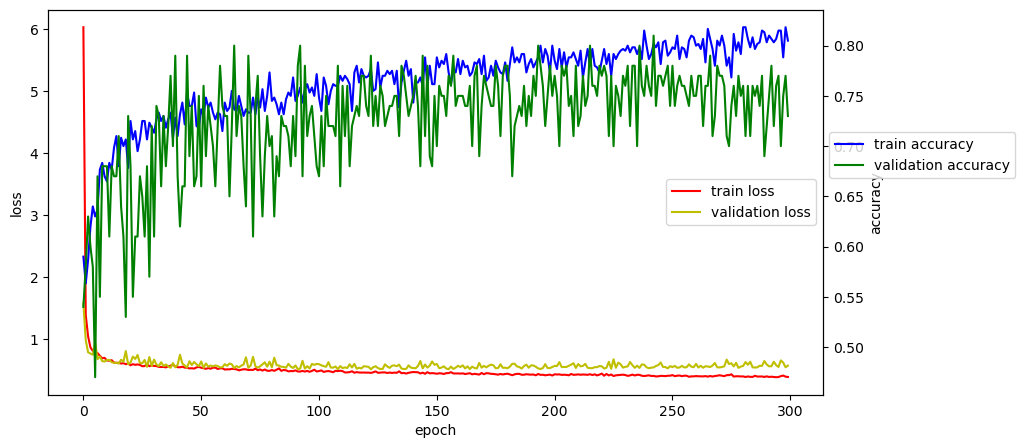

In [37]:
# 학습과정 표시하기(validation dataset 있는 경우)
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], 'r', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'y', label='validation loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'b', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'g', label='validation accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend(bbox_to_anchor=(0.999, 0.7))
plt.show()

In [38]:
# 모델 평가
score = model.evaluate(X_test, Y_test)
print("loss : {}, 정확도 : {}%".format(score[0], score[1]*100))

3/3 [==============================] - 0s 8ms/step - loss: 0.5999 - accuracy: 0.7500
loss : 0.5999135375022888, 정확도 : 75.0%


In [41]:
# 모델 사용
y_hat = model.predict(X_test).argmax(axis=1)
y_hat = np.argmax(model.predict(X_test), axis=1)
y_hat

3/3 [==============================] - 0s 3ms/step


array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0], dtype=int64)

In [40]:
all(Y_test.argmax(axis=1) == y_test)

True

In [46]:
# 교차표
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0.0,36,5
1.0,12,15


## 6. 모델 사용하기

In [17]:
X_test[1]

array([  6.   , 125.   ,  78.   ,  31.   ,   0.   ,  27.6  ,   0.565,
        49.   ])

In [43]:
pred = model.predict(np.array([[6, 125, 78, 31, 0, 27.6, 0.565, 49],
                               [6, 125, 78, 31, 0, 27.6, 0.565, 61]]))
print(pred)

1/1 [==============================] - 0s 35ms/step
[[0.8827408  0.11725923]
 [0.947235   0.05276503]]


In [44]:
pred.argmax(axis=1)

array([0, 0], dtype=int64)

In [45]:
np.argmax(pred, axis=1)

array([0, 0], dtype=int64)